In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def align_image(base_img, img_to_align, tx=0, ty=0, scale=1.0, angle=0.0):
    """
    Aligns img_to_align to base_img using an affine transformation.
    """
    rows, cols = base_img.shape
    
    # 1. Create a matrix for rotation and scaling around the image center
    center = (cols / 2, rows / 2)
    M = cv2.getRotationMatrix2D(center, angle, scale)
    
    # 2. Add the translation (shift in X and Y)
    M[0, 2] += tx  # Shift right/left
    M[1, 2] += ty  # Shift down/up
    
    # 3. Apply the geometric transformation to the image pixels
    # BORDER_REPLICATE fills empty edges created by shifting with the nearest edge pixel
    aligned_img = cv2.warpAffine(img_to_align, M, (cols, rows), borderMode=cv2.BORDER_REPLICATE)
    
    return aligned_img

In [3]:
def visualize_alignment(img1, img2_aligned, title="Alignment Check"):
    overlay = cv2.addWeighted(img1, 0.5, img2_aligned, 0.5, 0)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img1, cmap='gray')
    axes[0].set_title("Image 1 (Base)")
    axes[0].axis('off')
    
    axes[1].imshow(img2_aligned, cmap='gray')
    axes[1].set_title("Image 2 (Aligned)")
    axes[1].axis('off')
    
    axes[2].imshow(overlay, cmap='gray')
    axes[2].set_title(f"Overlay: {title}")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

In [4]:
img1 = cv2.imread('./einstein.webp', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('./marilyn.jpeg', cv2.IMREAD_GRAYSCALE)

img1 = cv2.resize(img1, (512, 512))
img2 = cv2.resize(img2, (512, 512))

# This function runs every time we move a slider
def update_alignment(val):
    # Read the current position of the sliders
    # We subtract numbers so we can have negative shifts and angles
    tx = cv2.getTrackbarPos('X Shift', 'Interactive Alignment') - 100
    ty = cv2.getTrackbarPos('Y Shift', 'Interactive Alignment') - 100
    scale = cv2.getTrackbarPos('Scale (%)', 'Interactive Alignment') / 100.0
    angle = cv2.getTrackbarPos('Angle', 'Interactive Alignment') - 180
    
    # Apply the Affine Transformation
    rows, cols = img1.shape
    M = cv2.getRotationMatrix2D((cols / 2, rows / 2), angle, scale)
    M[0, 2] += tx
    M[1, 2] += ty
    aligned_img2 = cv2.warpAffine(img2, M, (cols, rows), borderMode=cv2.BORDER_REPLICATE)
    
    # Create the 50% overlay
    overlay = cv2.addWeighted(img1, 0.5, aligned_img2, 0.5, 0)
    
    # Display the result
    cv2.imshow('Interactive Alignment', overlay)
    
    # Print the current values to the console so you can copy them later!
    print(f"Current Settings -> tx: {tx}, ty: {ty}, scale: {scale}, angle: {angle}", end='\r')

# Create the Window and the Sliders (Trackbars)
cv2.namedWindow('Interactive Alignment')

# cv2.createTrackbar('Name', 'Window', default_value, max_value, function)
cv2.createTrackbar('X Shift', 'Interactive Alignment', 100, 200, update_alignment)
cv2.createTrackbar('Y Shift', 'Interactive Alignment', 100, 200, update_alignment)
cv2.createTrackbar('Scale (%)', 'Interactive Alignment', 100, 300, update_alignment)
cv2.createTrackbar('Angle', 'Interactive Alignment', 180, 360, update_alignment)

# Show the initial image
update_alignment(0)

print("Use the sliders in the popup window to align the eyes and mouths.")
print("Press any key inside the image window to close it when you are done.")

# Wait until you press a key, then close the window
cv2.waitKey(0)
cv2.destroyAllWindows()

Use the sliders in the popup window to align the eyes and mouths.
Press any key inside the image window to close it when you are done.


From the above, we got  
tx=22  
ty= 44  
scale=1.12  
angle=0  
for first pair

In [5]:
img1 = cv2.imread('./cat.jpeg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('./dog.webp', cv2.IMREAD_GRAYSCALE)

img1 = cv2.resize(img1, (512, 512))
img2 = cv2.resize(img2, (512, 512))

# This function runs every time we move a slider
def update_alignment(val):
    # Read the current position of the sliders
    # We subtract numbers so we can have negative shifts and angles
    tx = cv2.getTrackbarPos('X Shift', 'Interactive Alignment') - 100
    ty = cv2.getTrackbarPos('Y Shift', 'Interactive Alignment') - 100
    scale = cv2.getTrackbarPos('Scale (%)', 'Interactive Alignment') / 100.0
    angle = cv2.getTrackbarPos('Angle', 'Interactive Alignment') - 180
    
    # Apply the Affine Transformation
    rows, cols = img1.shape
    M = cv2.getRotationMatrix2D((cols / 2, rows / 2), angle, scale)
    M[0, 2] += tx
    M[1, 2] += ty
    aligned_img2 = cv2.warpAffine(img2, M, (cols, rows), borderMode=cv2.BORDER_REPLICATE)
    
    # Create the 50% overlay
    overlay = cv2.addWeighted(img1, 0.5, aligned_img2, 0.5, 0)
    
    # Display the result
    cv2.imshow('Interactive Alignment', overlay)
    
    # Print the current values to the console so you can copy them later!
    print(f"Current Settings -> tx: {tx}, ty: {ty}, scale: {scale}, angle: {angle}", end='\r')

# Create the Window and the Sliders (Trackbars)
cv2.namedWindow('Interactive Alignment')

# cv2.createTrackbar('Name', 'Window', default_value, max_value, function)
cv2.createTrackbar('X Shift', 'Interactive Alignment', 100, 200, update_alignment)
cv2.createTrackbar('Y Shift', 'Interactive Alignment', 100, 200, update_alignment)
cv2.createTrackbar('Scale (%)', 'Interactive Alignment', 100, 300, update_alignment)
cv2.createTrackbar('Angle', 'Interactive Alignment', 180, 360, update_alignment)

# Show the initial image
update_alignment(0)

print("Use the sliders in the popup window to align the eyes and mouths.")
print("Press any key inside the image window to close it when you are done.")

# Wait until you press a key, then close the window
cv2.waitKey(0)
cv2.destroyAllWindows()

Use the sliders in the popup window to align the eyes and mouths.
Press any key inside the image window to close it when you are done.


For second pair, we got  
tx = 6  
ty = 16  
scale = 1.25  
angle = -8

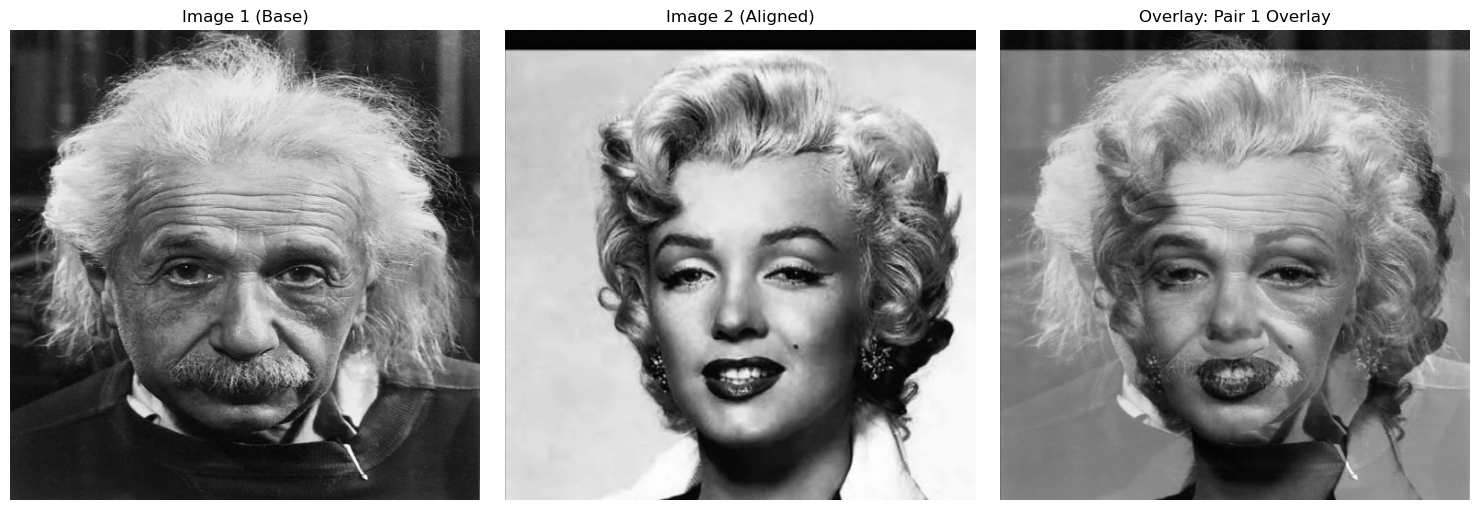

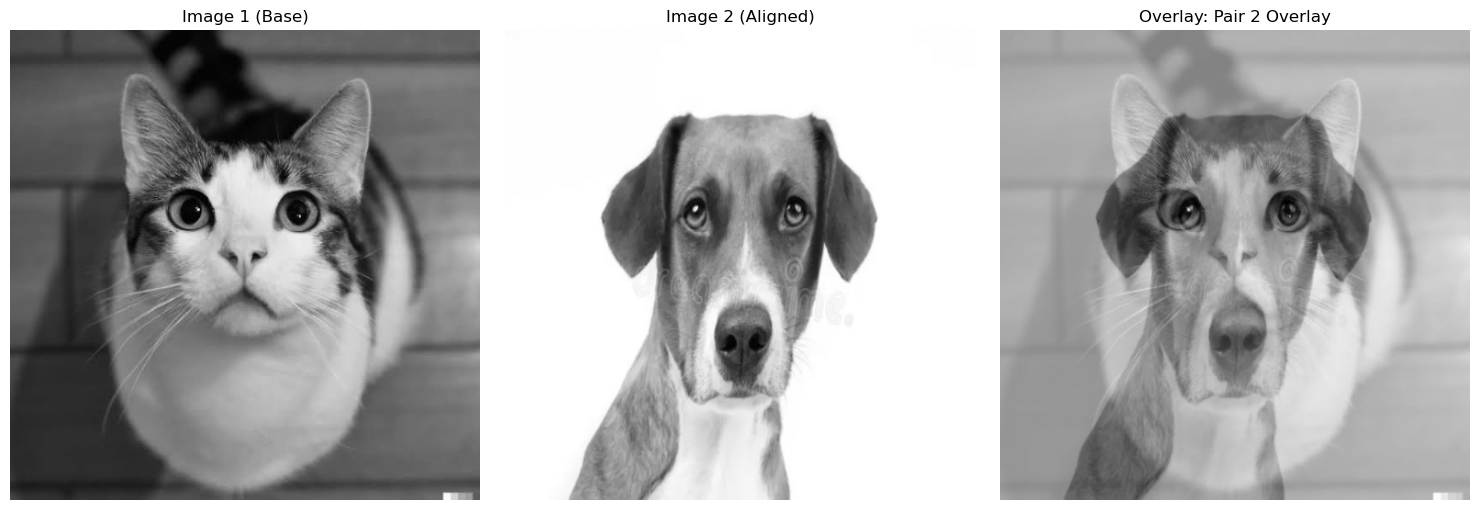

In [6]:
pair1_img1 = cv2.imread('./einstein.webp', cv2.IMREAD_GRAYSCALE)
pair1_img2 = cv2.imread('./marilyn.jpeg', cv2.IMREAD_GRAYSCALE)

pair1_img1 = cv2.resize(pair1_img1, (512, 512))
pair1_img2 = cv2.resize(pair1_img2, (512, 512))

p1_aligned = align_image(pair1_img1, pair1_img2, tx=22, ty=44, scale=1.12, angle=0)
visualize_alignment(pair1_img1, p1_aligned, "Pair 1 Overlay")

pair2_img1 = cv2.imread('./cat.jpeg', cv2.IMREAD_GRAYSCALE)
pair2_img2 = cv2.imread('./dog.webp', cv2.IMREAD_GRAYSCALE)

pair2_img1 = cv2.resize(pair2_img1, (512, 512))
pair2_img2 = cv2.resize(pair2_img2, (512, 512))

p2_aligned = align_image(pair2_img1, pair2_img2, tx=6, ty=16, scale=1.25, angle=-8)
visualize_alignment(pair2_img1, p2_aligned, "Pair 2 Overlay")

In [7]:
def create_spatial_hybrid(img1, img2, k_size=31, sigma=5, alpha=1.0, beta=1.0):
    img1_f = img1.astype(np.float32)
    img2_f = img2.astype(np.float32)
    
    lpf_img1 = cv2.GaussianBlur(img1_f, (k_size, k_size), sigma)
    
    lpf_img2 = cv2.GaussianBlur(img2_f, (k_size, k_size), sigma)
    hpf_img2 = img2_f - lpf_img2  # This contains NEGATIVE values!
    
    hybrid_f = (alpha * lpf_img1) + (beta * hpf_img2)
    
    # Clip values back to valid pixel range and convert to uint8
    hybrid_final = np.clip(hybrid_f, 0, 255).astype(np.uint8)
    
    # NORMALIZE HPF ONLY FOR VISUALIZATION (As strictly required by the PDF note)
    # This shifts the negative numbers so 0 becomes grey, negative becomes black, positive becomes white
    hpf_viz = cv2.normalize(hpf_img2, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    return lpf_img1.astype(np.uint8), hpf_viz, hybrid_final

In [8]:
K_SIZE = 15      # Must be odd
SIGMA = 5        # Controls the spread of the blur (cutoff frequency)
ALPHA = 0.8      # Weight of the blurry image
BETA = 1.0       # Weight of the sharp edges

In [9]:
lpf, hpf_vis, hybrid = create_spatial_hybrid(pair1_img1, p1_aligned, K_SIZE, SIGMA, ALPHA, BETA)

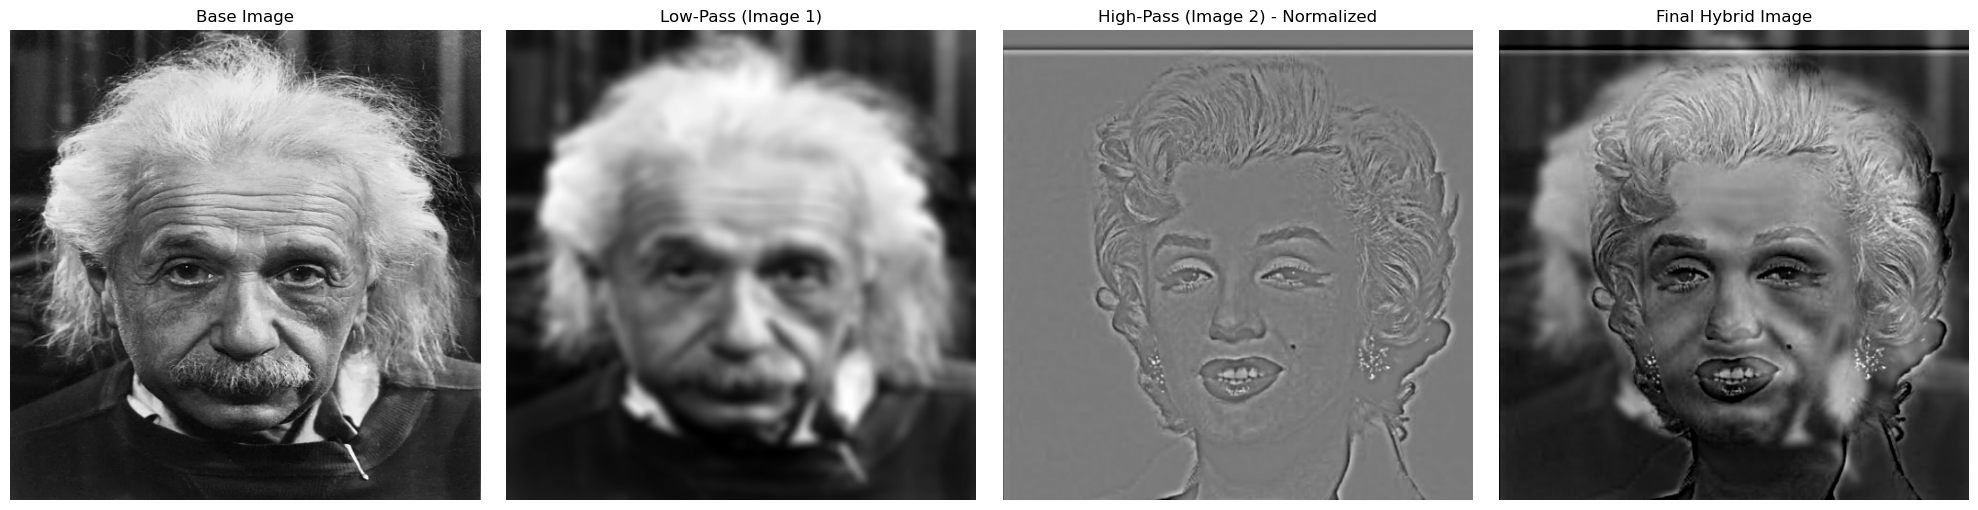

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(pair1_img1, cmap='gray')
axes[0].set_title("Base Image")
axes[0].axis('off')

axes[1].imshow(lpf, cmap='gray')
axes[1].set_title("Low-Pass (Image 1)")
axes[1].axis('off')

axes[2].imshow(hpf_vis, cmap='gray')
axes[2].set_title("High-Pass (Image 2) - Normalized")
axes[2].axis('off')

axes[3].imshow(hybrid, cmap='gray')
axes[3].set_title("Final Hybrid Image")
axes[3].axis('off')

plt.tight_layout()
plt.show()

In [11]:
import time

In [12]:
def create_frequency_hybrid(img1, img2, D0=30, alpha=0.6, beta=1.0):
    rows, cols = img1.shape
    
    # 1. Forward FFT: Convert to frequency domain and shift center
    F1 = np.fft.fftshift(np.fft.fft2(img1))
    F2 = np.fft.fftshift(np.fft.fft2(img2))
    
    # 2. Create the Gaussian Filter masks
    # Calculate distance D(u,v) from center for every pixel
    u = np.arange(rows) - rows / 2
    v = np.arange(cols) - cols / 2
    U, V = np.meshgrid(v, u)
    D = np.sqrt(U**2 + V**2)
    
    # Create LPF (Gaussian bell curve peaking at 1 in the center)
    H_LPF = np.exp(-(D**2) / (2 * (D0**2)))
    # Create HPF (Inverse of LPF)
    H_HPF = 1.0 - H_LPF
    
    # 3. Apply filters in the frequency domain (Simple multiplication!)
    G1 = F1 * H_LPF
    G2 = F2 * H_HPF
    
    # 4. Combine frequencies
    G_hybrid = (alpha * G1) + (beta * G2)
    
    # 5. Inverse FFT: Unshift and convert back to spatial domain
    hybrid_shifted = np.fft.ifftshift(G_hybrid)
    hybrid_spatial = np.fft.ifft2(hybrid_shifted)
    
    # Take the real part (FFT math generates complex numbers)
    hybrid_real = np.real(hybrid_spatial)
    
    # Clip and convert
    hybrid_final = np.clip(hybrid_real, 0, 255).astype(np.uint8)
    
    return hybrid_final, H_LPF, H_HPF

In [13]:
start_spatial = time.time()
_, _, spatial_result = create_spatial_hybrid(pair1_img1, p1_aligned, k_size=31, sigma=5, alpha=0.6, beta=1.0)
time_spatial = time.time() - start_spatial

In [14]:
start_freq = time.time()
freq_result, lpf_mask, hpf_mask = create_frequency_hybrid(pair1_img1, p1_aligned, D0=25, alpha=0.6, beta=1.0)
time_freq = time.time() - start_freq

print(f"Execution Time (Spatial): {time_spatial:.4f} seconds")
print(f"Execution Time (Frequency): {time_freq:.4f} seconds")

Execution Time (Spatial): 0.0085 seconds
Execution Time (Frequency): 0.9521 seconds


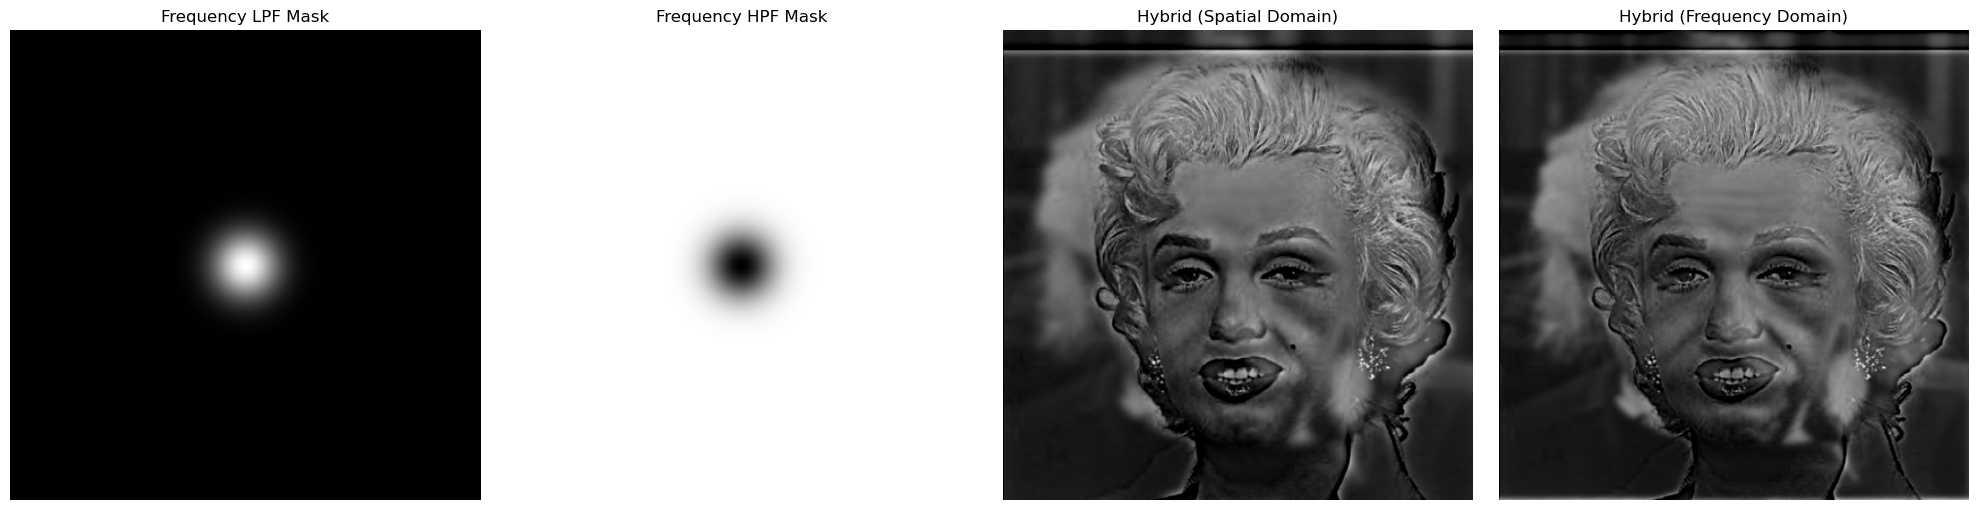

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(lpf_mask, cmap='gray')
axes[0].set_title("Frequency LPF Mask")
axes[0].axis('off')

axes[1].imshow(hpf_mask, cmap='gray')
axes[1].set_title("Frequency HPF Mask")
axes[1].axis('off')

axes[2].imshow(spatial_result, cmap='gray')
axes[2].set_title("Hybrid (Spatial Domain)")
axes[2].axis('off')

axes[3].imshow(freq_result, cmap='gray')
axes[3].set_title("Hybrid (Frequency Domain)")
axes[3].axis('off')

plt.tight_layout()
plt.show()

In [16]:
def generate_pyramids(img, levels=4, use_bilateral=False):
    """Generates Gaussian and Laplacian pyramids."""
    G = img.copy().astype(np.float32)
    gp = [G]
    
    # Build Gaussian Pyramid
    for i in range(levels):
        if use_bilateral:
            # Bilateral filter: d=9, sigmaColor=75, sigmaSpace=75
            blurred = cv2.bilateralFilter(G, 9, 75, 75)
        else:
            blurred = cv2.GaussianBlur(G, (5, 5), 0)
            
        # Downsample (take every second pixel)
        G = blurred[::2, ::2]
        gp.append(G)
        
    # Build Laplacian Pyramid
    lp = [gp[levels]]
    for i in range(levels, 0, -1):
        # Upsample the smaller image to match the size of the current level
        h, w = gp[i-1].shape
        GE = cv2.resize(gp[i], (w, h), interpolation=cv2.INTER_LINEAR)
        # Laplacian = Current Gaussian - Upsampled Next Gaussian
        L = gp[i-1] - GE
        lp.append(L)
        
    # Reverse Laplacian pyramid so lp[0] is the finest resolution
    lp = lp[::-1] 
    return gp, lp

In [17]:
def reconstruct_from_pyramid(lp):
    """Collapses the Laplacian pyramid to reconstruct the image."""
    ls_ = lp[-1] # The smallest blurry base
    for i in range(len(lp)-2, -1, -1):
        h, w = lp[i].shape
        ls_ = cv2.resize(ls_, (w, h), interpolation=cv2.INTER_LINEAR)
        ls_ += lp[i]
    return np.clip(ls_, 0, 255).astype(np.uint8)

In [19]:
LEVELS = 4

# 1. Standard Pyramids (Gaussian)
gp1, lp1 = generate_pyramids(pair1_img1, LEVELS, use_bilateral=False)
gp2, lp2 = generate_pyramids(p1_aligned, LEVELS, use_bilateral=False)

# Mix: Take bottom levels (details) from Image 2, top levels (shapes) from Image 1
lp_hybrid = []
for i in range(LEVELS + 1):
    if i < 2:  # High frequency levels (fine details)
        lp_hybrid.append(lp2[i])
    else:      # Low frequency levels (broad shapes)
        lp_hybrid.append(lp1[i])

hybrid_pyramid_result = reconstruct_from_pyramid(lp_hybrid)

# Bilateral Pyramids
bgp1, blp1 = generate_pyramids(pair1_img1, LEVELS, use_bilateral=True)
bgp2, blp2 = generate_pyramids(p1_aligned, LEVELS, use_bilateral=True)

# Mix Bilateral exactly the same way
blp_hybrid = []
for i in range(LEVELS + 1):
    if i < 2:
        blp_hybrid.append(blp2[i])
    else:
        blp_hybrid.append(blp1[i])

hybrid_bilateral_result = reconstruct_from_pyramid(blp_hybrid)

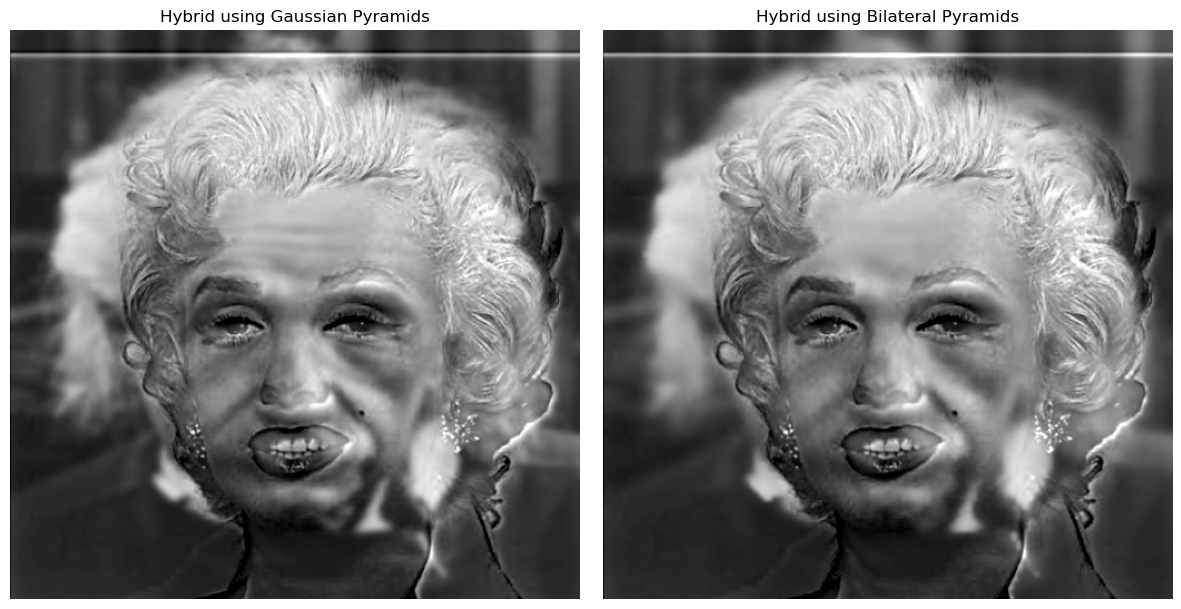

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(hybrid_pyramid_result, cmap='gray')
axes[0].set_title("Hybrid using Gaussian Pyramids")
axes[0].axis('off')

axes[1].imshow(hybrid_bilateral_result, cmap='gray')
axes[1].set_title("Hybrid using Bilateral Pyramids")
axes[1].axis('off')

plt.tight_layout()
plt.show()